In [46]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [47]:
# Loading data 
dataset = pd.read_csv("../../Data/1) Iris.csv")
print(dataset.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [48]:
# Display all dataset details
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [49]:
# Checking Missing values
print(dataset.isna().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [50]:
# Checking duplicated values
print(dataset.duplicated().sum())

3


In [51]:
# Droping duplicated values
dataset = dataset.drop_duplicates()

In [52]:
# Unique flower species name
species_names = []
species_names = dataset['species'].unique()
print(species_names)

['setosa' 'versicolor' 'virginica']


In [53]:
# Categorical mapping to numerical 
dataset['species'] = dataset['species'].map({'setosa':1 , 'versicolor':2, 'virginica':3})

In [54]:
# Dataset shape
dataset.shape

(147, 5)

In [55]:
# Feature Selection
data = dataset.values
X = data[:,0:4]
y = data[:,4]

print(X.shape)
print(y.shape)

(147, 4)
(147,)


In [56]:
# Train/Test Split
# 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [57]:
# Shape of splitted train and test set
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(117, 4) (30, 4)
(117,) (30,)


In [58]:
# Decision Tree Classifier model
dtc = DecisionTreeClassifier()

# Fitting model
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

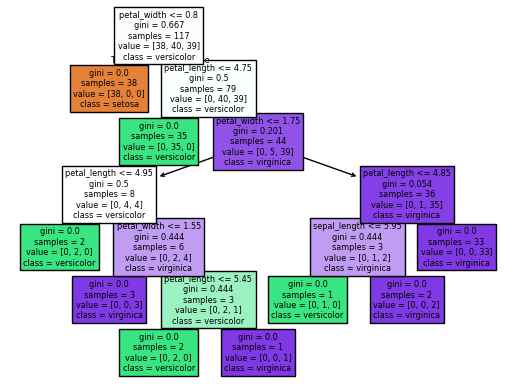

In [ ]:
# Visualize the decision tree
plot_tree(dtc,
          feature_names=dataset.columns[:4],
          class_names=species_names,
          filled=True)
plt.show()

In [60]:
# Prediction
y_pred = dtc.predict(X_test)

# Metrices
accuracy = accuracy_score(y_test,y_pred)
f1_scr = f1_score(y_test,y_pred,average="weighted")

print("Accuracy:",accuracy)
print("F1 Score:",f1_scr)

Accuracy: 0.9666666666666667
F1 Score: 0.9665831244778613


In [61]:
# Pruned Decision Tree Clasifier model
dtc_pruned = DecisionTreeClassifier(max_depth=3, random_state=0)

# Fitting model
dtc_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

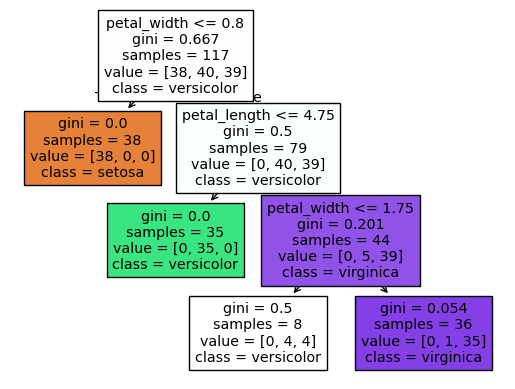

In [62]:
# Visualize pruned tree
plot_tree(dtc_pruned,    
          feature_names=dataset.columns[:4],
          class_names=species_names,
          filled=True)
plt.show()

In [63]:
# Prediction
y_pred_pruned = dtc_pruned.predict(X_test)

# Metrices
accuracy_pruned = accuracy_score(y_test,y_pred_pruned)
f1_scr_pruned = f1_score(y_test,y_pred_pruned,average="weighted")

print("Pruned Accuracy:",accuracy_pruned)
print("Pruned F1 Score:",f1_scr_pruned)

Pruned Accuracy: 0.9666666666666667
Pruned F1 Score: 0.9665831244778613


In [64]:
# Checking if the prediction of the original tree model and pruned tree model are different or not
print("\nNumber of different predictions:", sum(y_pred != y_pred_pruned))


Number of different predictions: 0


In [65]:
# Tree depth 
print("Original tree depth:", dtc.get_depth())
print("Pruned tree depth:", dtc_pruned.get_depth())

# No of Leaves
print("Original number of leaves:", dtc.get_n_leaves())
print("Pruned number of leaves:", dtc_pruned.get_n_leaves())

Original tree depth: 6
Pruned tree depth: 3
Original number of leaves: 9
Pruned number of leaves: 4


In [66]:
# Table of comparison 
results = pd.DataFrame({
    "Model": ["Original Decision Tree", "Pruned Decision Tree"],
    "Accuracy": [accuracy, accuracy_pruned],
    "F1 Score": [f1_scr, f1_scr_pruned],
    "Tree Depth": [dtc.get_depth(), dtc_pruned.get_depth()],
    "No. of Leaves": [dtc.get_n_leaves(), dtc_pruned.get_n_leaves()]
})

print(results)

                    Model  Accuracy  F1 Score  Tree Depth  No. of Leaves
0  Original Decision Tree  0.966667  0.966583           6              9
1    Pruned Decision Tree  0.966667  0.966583           3              4
